# Anthropic Job Descriptions: NLP & Text Analysis

Using the `description_md` field from `anthropic_salaries.csv` to extract insights
about skills, experience requirements, and language patterns across departments.

In [ ]:
# ── CONFIG ──────────────────────────────────────────────────────────
CSV_PATH = "anthropic_salaries.csv"
# ────────────────────────────────────────────────────────────────────

import re

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

from classify import (
    classify_department, classify_seniority, classify_work_mode,
    add_classifications, add_usd_salary, TO_USD, SENIORITY_ORDER,
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

## Data Loading

In [ ]:
df = pd.read_csv(CSV_PATH, dtype={"job_id": str})
add_classifications(df)
add_usd_salary(df)
df_nlp = df.copy()

descs = df_nlp["description_md"].dropna()
print(f"Jobs with descriptions: {len(descs)}/{len(df_nlp)}")
print(f"Avg description length: {descs.str.len().mean():,.0f} chars")

## NLP-1. Skills & Technology Keywords

Extract the most-mentioned technologies, tools, and skills across all job descriptions.

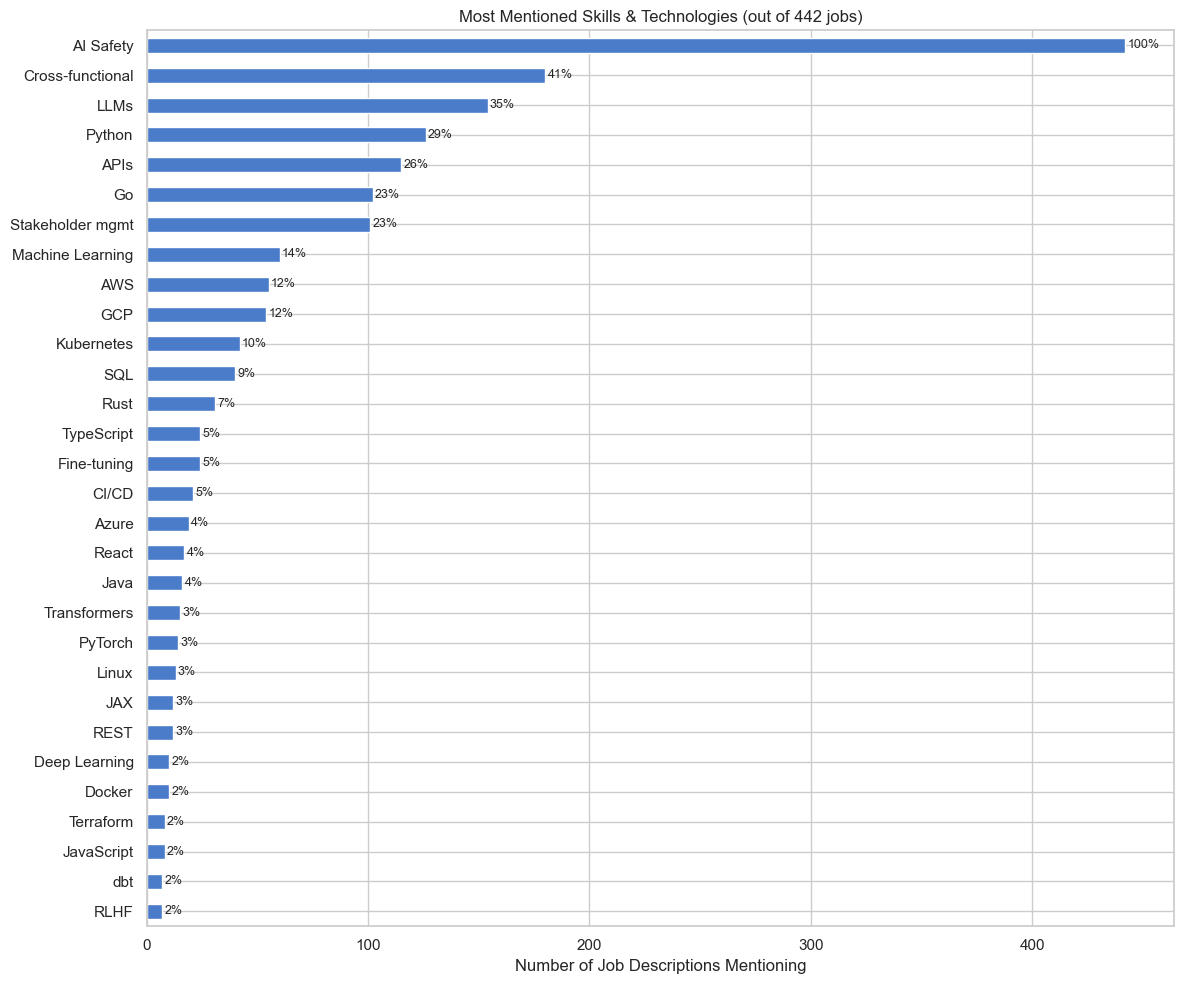

In [14]:
# Curated skill/technology keywords to search for in descriptions
SKILL_KEYWORDS = {
    # Languages
    "Python": r"\bPython\b", "Java": r"\bJava\b(?!Script)", "JavaScript": r"\bJavaScript\b",
    "TypeScript": r"\bTypeScript\b", "Go": r"\bGo(?:lang)?\b", "Rust": r"\bRust\b",
    "C/C++": r"\bC\+\+\b|\bC programming\b", "SQL": r"\bSQL\b", "R": r"\bR\b(?= programming| language| (?:and|or) )",
    "Scala": r"\bScala\b", "Kotlin": r"\bKotlin\b", "Ruby": r"\bRuby\b",
    # ML/AI
    "PyTorch": r"\bPyTorch\b", "TensorFlow": r"\bTensorFlow\b", "JAX": r"\bJAX\b",
    "LLMs": r"\bLLM[s]?\b|large language model", "NLP": r"\bNLP\b|natural language processing",
    "Deep Learning": r"\bdeep learning\b", "Machine Learning": r"\bmachine learning\b",
    "Transformers": r"\btransformer[s]?\b", "RLHF": r"\bRLHF\b",
    "Fine-tuning": r"\bfine[- ]?tun", "RAG": r"\bRAG\b",
    # Infrastructure
    "AWS": r"\bAWS\b", "GCP": r"\bGCP\b|Google Cloud", "Azure": r"\bAzure\b",
    "Kubernetes": r"\bKubernetes\b|\bk8s\b", "Docker": r"\bDocker\b",
    "Terraform": r"\bTerraform\b", "Linux": r"\bLinux\b",
    # Data
    "Spark": r"\bSpark\b", "Snowflake": r"\bSnowflake\b", "dbt": r"\bdbt\b",
    "Postgres": r"\bPostgres\b|\bPostgreSQL\b", "Redis": r"\bRedis\b",
    # Tools & Practices
    "Git": r"\bGit\b(?!Hub)", "CI/CD": r"\bCI/?CD\b", "Agile": r"\bAgile\b|\bScrum\b",
    "React": r"\bReact\b", "Node.js": r"\bNode\.?js\b",
    "APIs": r"\bAPI[s]?\b", "GraphQL": r"\bGraphQL\b", "REST": r"\bREST\b(?:ful)?",
    # Soft skills / domain
    "Cross-functional": r"\bcross[- ]?functional\b", "Stakeholder mgmt": r"\bstakeholder\b",
    "AI Safety": r"\bAI safety\b|\bsafety research\b",
}

# Count how many job descriptions mention each skill
skill_counts = {}
for skill, pattern in SKILL_KEYWORDS.items():
    count = df_nlp["description_md"].str.contains(pattern, flags=re.I, na=False).sum()
    if count > 0:
        skill_counts[skill] = count

skill_series = pd.Series(skill_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
skill_series.head(30).sort_values().plot.barh(ax=ax, color="#4a7cc9")
ax.set_title(f"Most Mentioned Skills & Technologies (out of {len(df_nlp)} jobs)")
ax.set_xlabel("Number of Job Descriptions Mentioning")
ax.set_ylabel("")
# Add percentage labels
for i, (skill, count) in enumerate(skill_series.head(30).sort_values().items()):
    ax.text(count + 1, i, f"{count/len(df_nlp)*100:.0f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

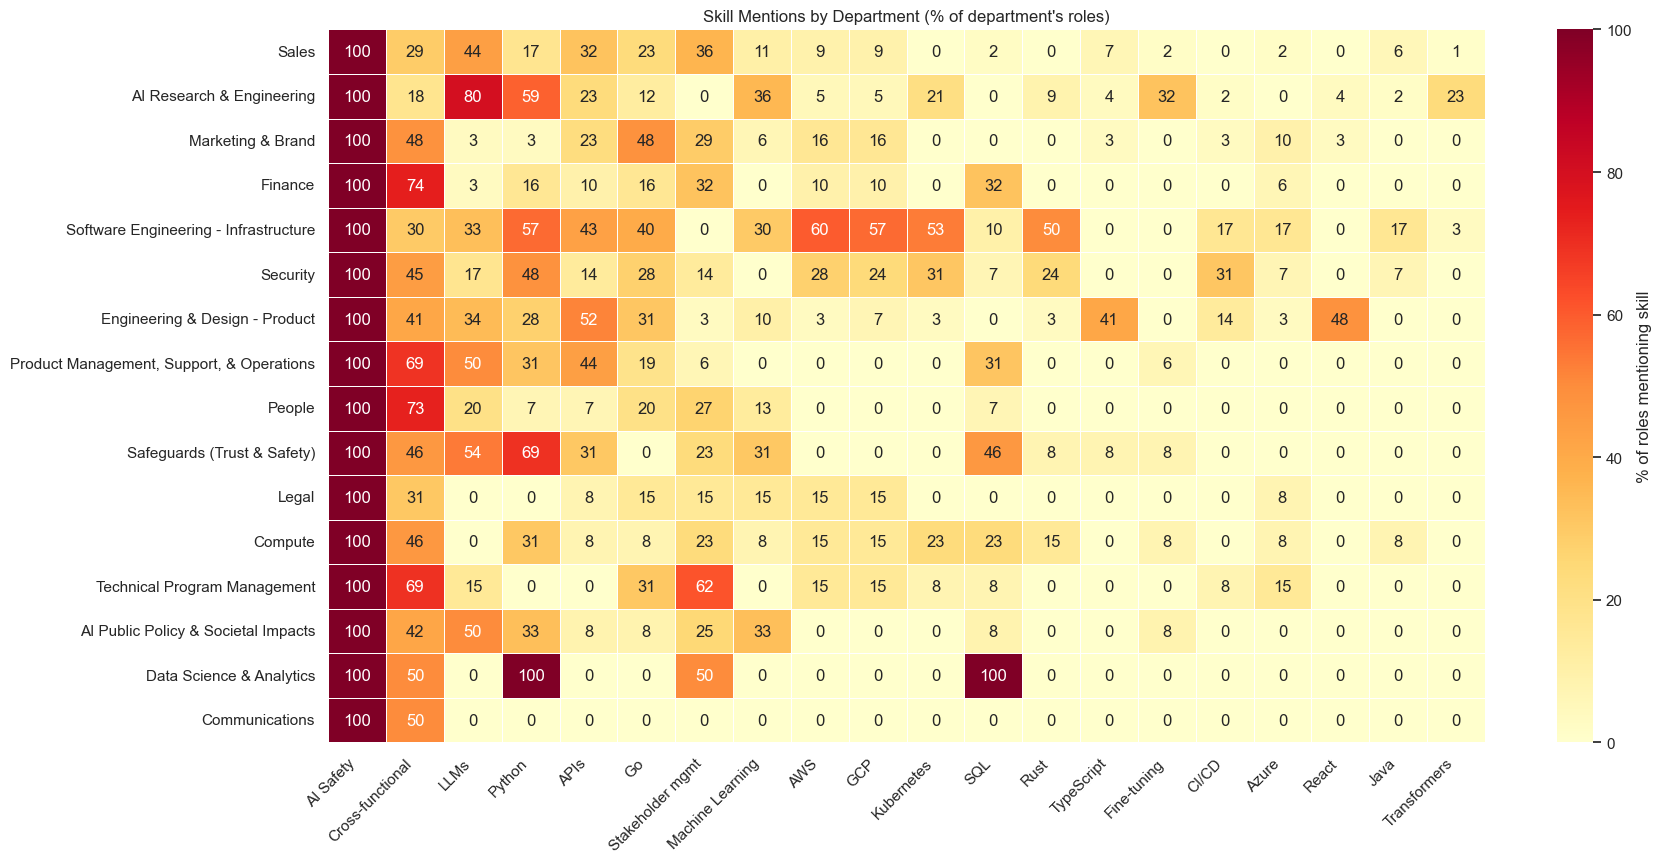

In [15]:
# Skills heatmap by department — which departments ask for which skills?
top_skills = skill_series.head(20).index.tolist()
top_dept_nlp = [d for d in df_nlp["department"].value_counts().index if d != "Other"]
dept_skill_matrix = pd.DataFrame(index=top_dept_nlp, columns=top_skills, dtype=float)

for dept in top_dept_nlp:
    dept_descs = df_nlp.loc[df_nlp["department"] == dept, "description_md"]
    n_dept = len(dept_descs)
    for skill in top_skills:
        pattern = SKILL_KEYWORDS[skill]
        count = dept_descs.str.contains(pattern, flags=re.I, na=False).sum()
        dept_skill_matrix.loc[dept, skill] = count / n_dept * 100 if n_dept > 0 else 0

fig, ax = plt.subplots(figsize=(18, max(7, len(top_dept_nlp) * 0.55)))
sns.heatmap(
    dept_skill_matrix.astype(float), annot=True, fmt=".0f", cmap="YlOrRd",
    linewidths=0.5, ax=ax, cbar_kws={"label": "% of roles mentioning skill"},
)
ax.set_title("Skill Mentions by Department (% of department's roles)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## NLP-2. Experience Requirements

Parse years-of-experience requirements from job descriptions.

Jobs with parseable YoE requirement: 370/442 (84%)
YoE range: 1 - 15 years
Median: 7 years, Mean: 6.9 years


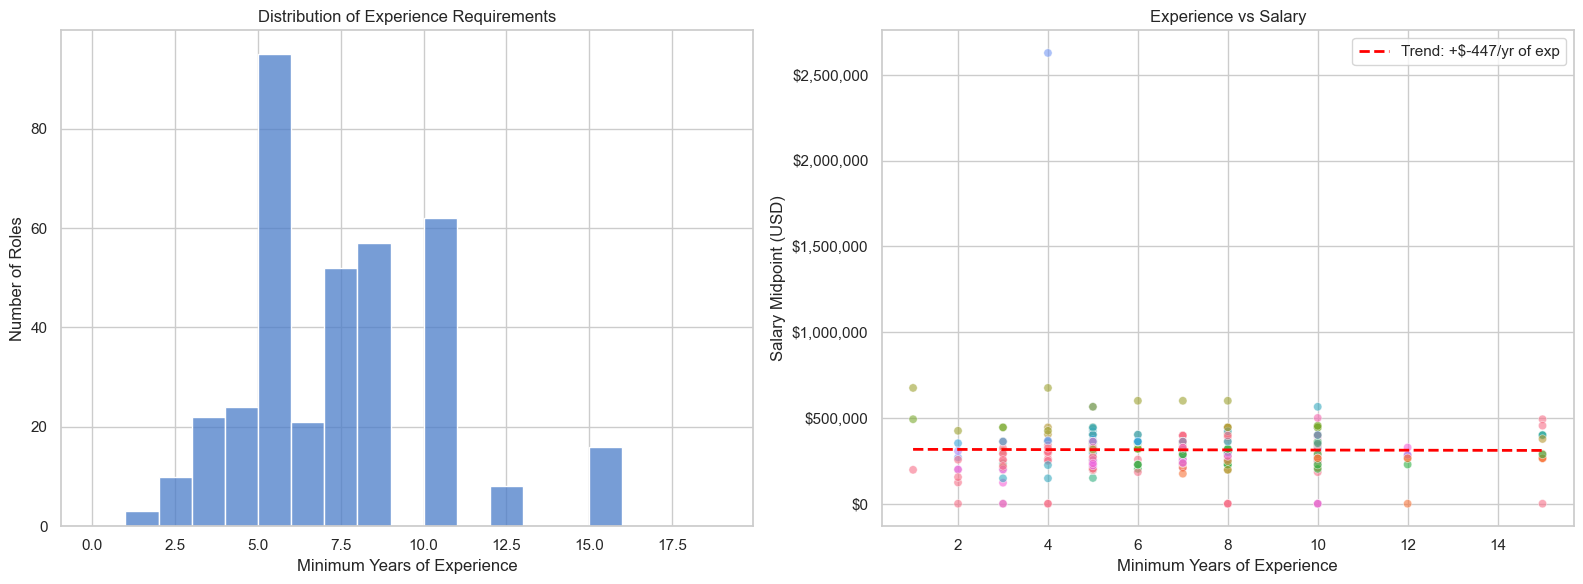

In [16]:
# Extract years of experience from descriptions
# Patterns like "5+ years", "3-5 years", "at least 7 years"
YOE_PATTERN = re.compile(
    r"(\d{1,2})\s*(?:\+|or more)?\s*(?:-\s*(\d{1,2})\s*)?(?:\+)?\s*years?\b"
    r"(?:\s+of\s+(?:relevant\s+|professional\s+|industry\s+|hands[- ]on\s+)?"
    r"(?:experience|work))?",
    re.I,
)

def extract_yoe(text):
    """Extract minimum years of experience from description."""
    if pd.isna(text):
        return None
    matches = YOE_PATTERN.findall(text)
    if not matches:
        return None
    # Take the max "minimum" mentioned (most roles list the primary req prominently)
    mins = [int(m[0]) for m in matches if 1 <= int(m[0]) <= 25]
    return max(mins) if mins else None

df_nlp["yoe"] = df_nlp["description_md"].apply(extract_yoe)
df_nlp_yoe = df_nlp.dropna(subset=["yoe"])

print(f"Jobs with parseable YoE requirement: {len(df_nlp_yoe)}/{len(df_nlp)} ({len(df_nlp_yoe)/len(df_nlp)*100:.0f}%)")
print(f"YoE range: {df_nlp_yoe['yoe'].min():.0f} - {df_nlp_yoe['yoe'].max():.0f} years")
print(f"Median: {df_nlp_yoe['yoe'].median():.0f} years, Mean: {df_nlp_yoe['yoe'].mean():.1f} years")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of YoE requirements
sns.histplot(df_nlp_yoe["yoe"], bins=range(0, 20), kde=False, ax=axes[0], color="#4a7cc9")
axes[0].set_title("Distribution of Experience Requirements")
axes[0].set_xlabel("Minimum Years of Experience")
axes[0].set_ylabel("Number of Roles")

# YoE vs salary
df_yoe_sal = df_nlp_yoe.dropna(subset=["mid_usd"])
if len(df_yoe_sal) > 10:
    sns.scatterplot(data=df_yoe_sal, x="yoe", y="mid_usd", hue="department",
                    alpha=0.6, ax=axes[1], legend=False)
    # Add trend line
    z = np.polyfit(df_yoe_sal["yoe"], df_yoe_sal["mid_usd"], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(df_yoe_sal["yoe"].min(), df_yoe_sal["yoe"].max(), 50)
    axes[1].plot(x_trend, p(x_trend), "--", color="red", linewidth=2,
                 label=f"Trend: +${z[0]:,.0f}/yr of exp")
    axes[1].set_title("Experience vs Salary")
    axes[1].set_xlabel("Minimum Years of Experience")
    axes[1].set_ylabel("Salary Midpoint (USD)")
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    axes[1].legend()

plt.tight_layout()
plt.show()

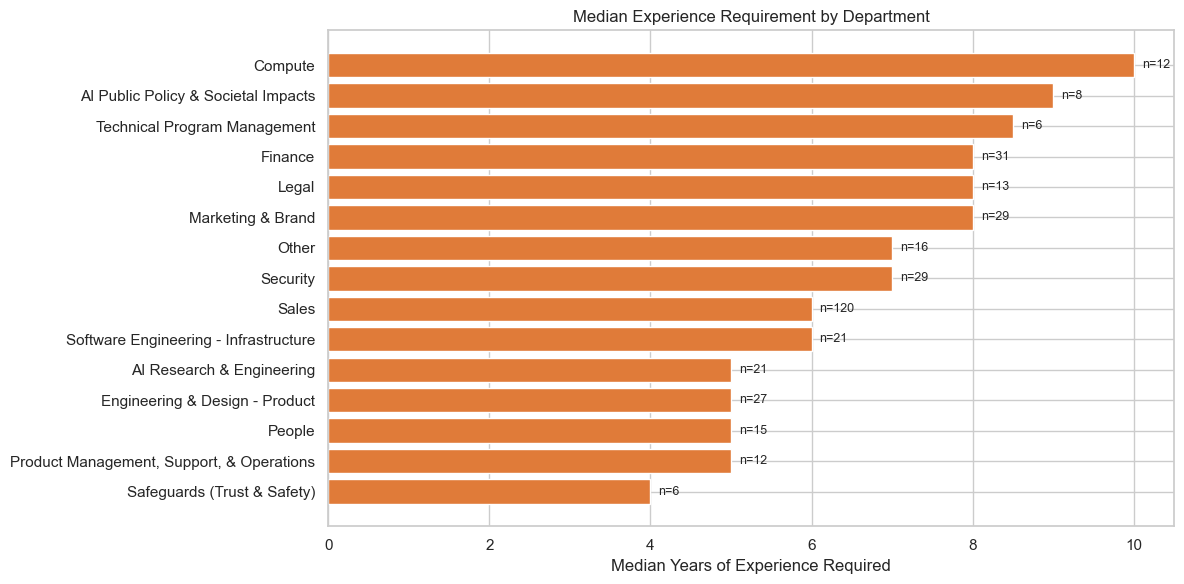

In [17]:
# YoE by department
dept_yoe = df_nlp_yoe.groupby("department")["yoe"].agg(["median", "mean", "count"])
dept_yoe = dept_yoe[dept_yoe["count"] >= 3].sort_values("median", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(dept_yoe.index, dept_yoe["median"], color="#e07b39")
ax.set_title("Median Experience Requirement by Department")
ax.set_xlabel("Median Years of Experience Required")
ax.set_ylabel("")
for bar, (_, row) in zip(bars, dept_yoe.iterrows()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['count'])}", va="center", fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## NLP-3. Word Clouds by Department

Visualize the most distinctive language used in each department's job descriptions.

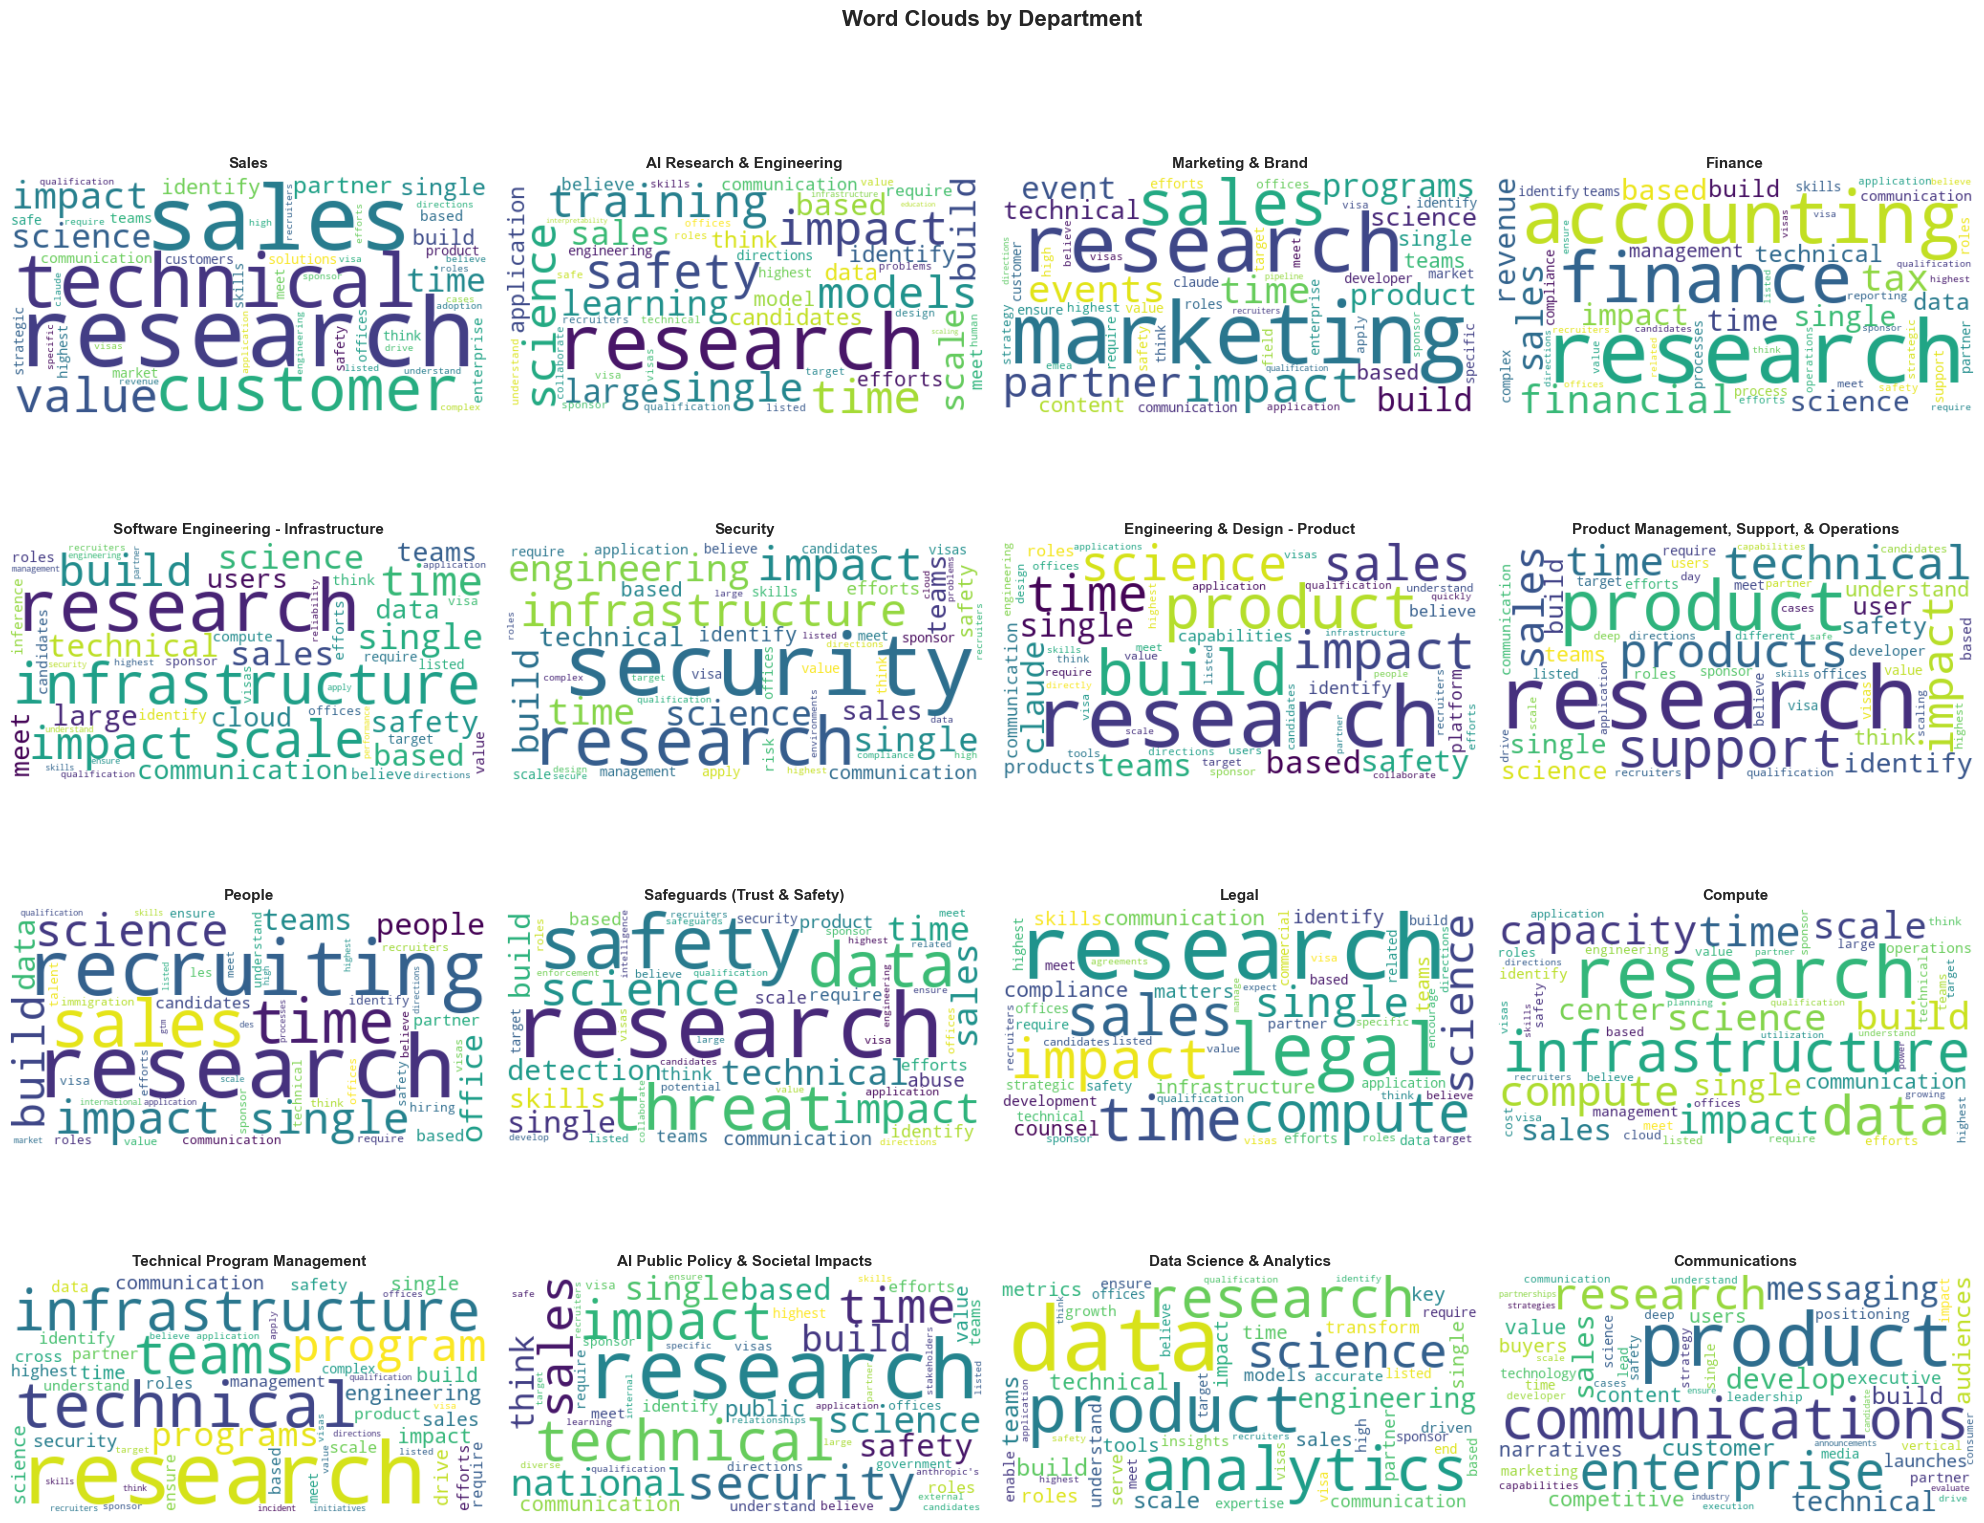

In [18]:
from collections import Counter
from wordcloud import WordCloud, STOPWORDS as _WC_STOPWORDS
import re as _re

# Comprehensive stopwords: wordcloud built-in + sklearn + custom Anthropic boilerplate
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as _SK_STOPWORDS
STOPWORDS = _WC_STOPWORDS | set(_SK_STOPWORDS) | set("""
    anthropic company team work role working will also join help us our we you your
    strong experience years including ability new across within well one may able use
    including make take first best mission create reliable interpretable steerable
    systems society whole group committed researchers engineers policy experts business
    leaders building beneficial position expected salary range annual compensation
    hybrid location san francisco new york seattle logistics requirements workspace
    offer benefits equity remote friendly travel required states united
""".split())

# Tokenize + count, excluding stopwords, before passing to WordCloud
_TOKEN_RE = _re.compile(r"[a-z][a-z']+")

def _word_freqs(text):
    tokens = _TOKEN_RE.findall(text.lower())
    counts = Counter(t for t in tokens if t not in STOPWORDS and len(t) > 2)
    return dict(counts.most_common(200))

# Exclude "Other" — show all real departments
wc_depts = [d for d in df_nlp["department"].value_counts().index if d != "Other"]
dept_texts = {}
for dept in wc_depts:
    texts = df_nlp.loc[df_nlp["department"] == dept, "description_md"].dropna()
    dept_texts[dept] = " ".join(texts)

# Filter out departments with too little text
wc_depts = [d for d in wc_depts if len(dept_texts[d]) > 100]

n = len(wc_depts)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
for ax, dept in zip(axes.flat, wc_depts):
    freqs = _word_freqs(dept_texts[dept])
    if not freqs:
        ax.set_visible(False)
        continue
    wc = WordCloud(
        width=500, height=250, background_color="white",
        max_words=50, colormap="viridis", prefer_horizontal=0.7,
    )
    wc.generate_from_frequencies(freqs)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(dept, fontsize=11, fontweight="bold")
    ax.axis("off")
# Hide unused axes
for ax in axes.flat[n:]:
    ax.set_visible(False)

fig.suptitle("Word Clouds by Department", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## NLP-4. Job Description Clustering

Use TF-IDF + dimensionality reduction to cluster jobs by description similarity
and visualize how roles naturally group together.

TF-IDF matrix: 442 jobs x 3000 features
SVD explained variance: 4.3%


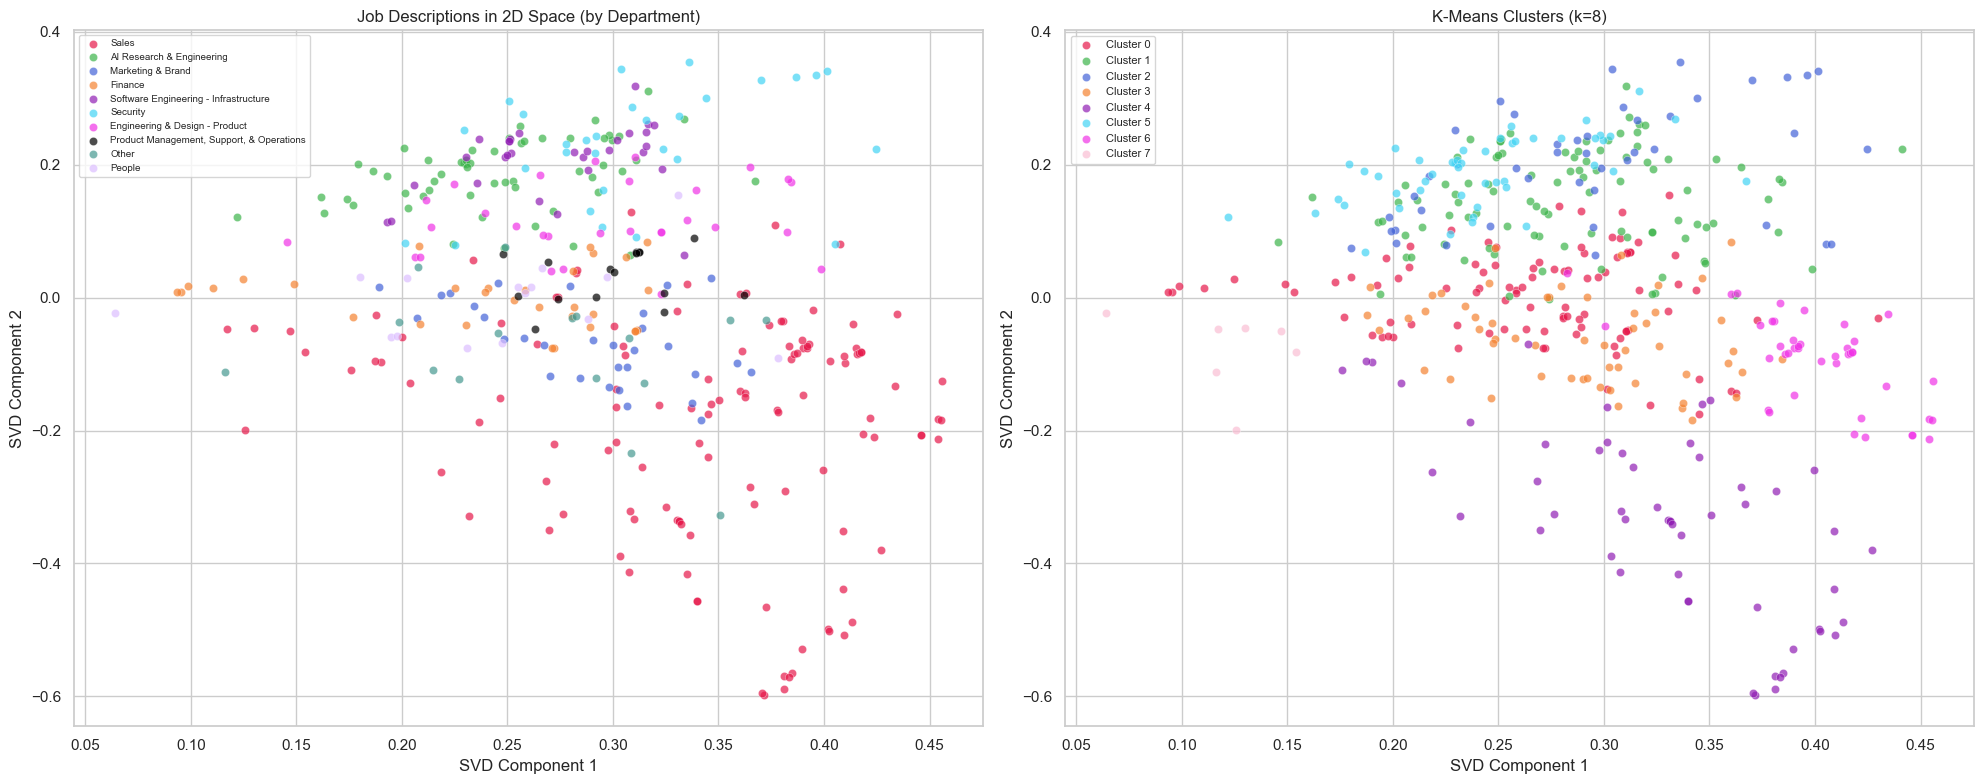

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

# TF-IDF vectorization
tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words="english",
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2),
)
df_cluster = df_nlp.dropna(subset=["description_md"]).copy()
tfidf_matrix = tfidf.fit_transform(df_cluster["description_md"])

# Reduce to 2D with SVD for visualization
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(tfidf_matrix)
df_cluster["x"] = coords[:, 0]
df_cluster["y"] = coords[:, 1]

print(f"TF-IDF matrix: {tfidf_matrix.shape[0]} jobs x {tfidf_matrix.shape[1]} features")
print(f"SVD explained variance: {svd.explained_variance_ratio_.sum()*100:.1f}%")

# High-contrast color palettes
# Index 7 = Product Management, Support, & Operations → black
dept_colors = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#42d4f4", "#f032e6", "#000000", "#469990", "#dcbeff",
]
cluster_colors = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#42d4f4", "#f032e6", "#fabed4",
]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# By department — top 10 for readability
top_scatter = df_cluster["department"].value_counts().head(10).index.tolist()
df_plot = df_cluster[df_cluster["department"].isin(top_scatter)]
for i, dept in enumerate(top_scatter):
    mask = df_plot["department"] == dept
    axes[0].scatter(df_plot.loc[mask, "x"], df_plot.loc[mask, "y"],
                    label=dept, alpha=0.7, s=35, color=dept_colors[i], edgecolors="white", linewidth=0.3)
axes[0].set_title("Job Descriptions in 2D Space (by Department)")
axes[0].set_xlabel("SVD Component 1")
axes[0].set_ylabel("SVD Component 2")
axes[0].legend(fontsize=7, loc="best")

# K-Means clustering
N_CLUSTERS = 8
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df_cluster["cluster"] = km.fit_predict(tfidf_matrix)

for c in range(N_CLUSTERS):
    mask = df_cluster["cluster"] == c
    axes[1].scatter(df_cluster.loc[mask, "x"], df_cluster.loc[mask, "y"],
                    label=f"Cluster {c}", alpha=0.7, s=35, color=cluster_colors[c], edgecolors="white", linewidth=0.3)
axes[1].set_title(f"K-Means Clusters (k={N_CLUSTERS})")
axes[1].set_xlabel("SVD Component 1")
axes[1].set_ylabel("SVD Component 2")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [20]:
# Characterize each cluster: top TF-IDF terms + department breakdown + median salary
feature_names = tfidf.get_feature_names_out()
order = km.cluster_centers_.argsort()[:, ::-1]

print("CLUSTER PROFILES")
print("=" * 90)
for c in range(N_CLUSTERS):
    cluster_mask = df_cluster["cluster"] == c
    n = cluster_mask.sum()
    top_terms = [feature_names[i] for i in order[c, :8]]
    top_dept = df_cluster.loc[cluster_mask, "department"].value_counts().head(3)
    dept_str = ", ".join(f"{d} ({cnt})" for d, cnt in top_dept.items())
    med_sal = df_cluster.loc[cluster_mask, "mid_usd"].median()
    sal_str = f"${med_sal:,.0f}" if not pd.isna(med_sal) else "N/A"

    print(f"\nCluster {c} ({n} roles, median salary: {sal_str})")
    print(f"  Top terms: {', '.join(top_terms)}")
    print(f"  Top depts: {dept_str}")

CLUSTER PROFILES

Cluster 0 (94 roles, median salary: $252,500)
  Top terms: finance, accounting, support, data, financial, legal, technical, management
  Top depts: Finance (31), Sales (13), Legal (13)

Cluster 1 (97 roles, median salary: $362,500)
  Top terms: infrastructure, product, data, engineering, technical, claude, inference, platform
  Top depts: Engineering & Design - Product (28), Software Engineering - Infrastructure (28), Compute (10)

Cluster 2 (44 roles, median salary: $323,750)
  Top terms: security, threat, detection, infrastructure, engineering, secure, response, intelligence
  Top depts: Security (26), Safeguards (Trust & Safety) (6), AI Research & Engineering (3)

Cluster 3 (56 roles, median salary: $265,000)
  Top terms: marketing, developer, events, content, event, programs, enterprise, product
  Top depts: Marketing & Brand (31), Sales (9), Other (5)

Cluster 4 (54 roles, median salary: $325,000)
  Top terms: market, revenue, strategic, enterprise, solutions, pr

## NLP-5. Education Requirements & Degree Preferences

Parse educational requirements mentioned across job descriptions.

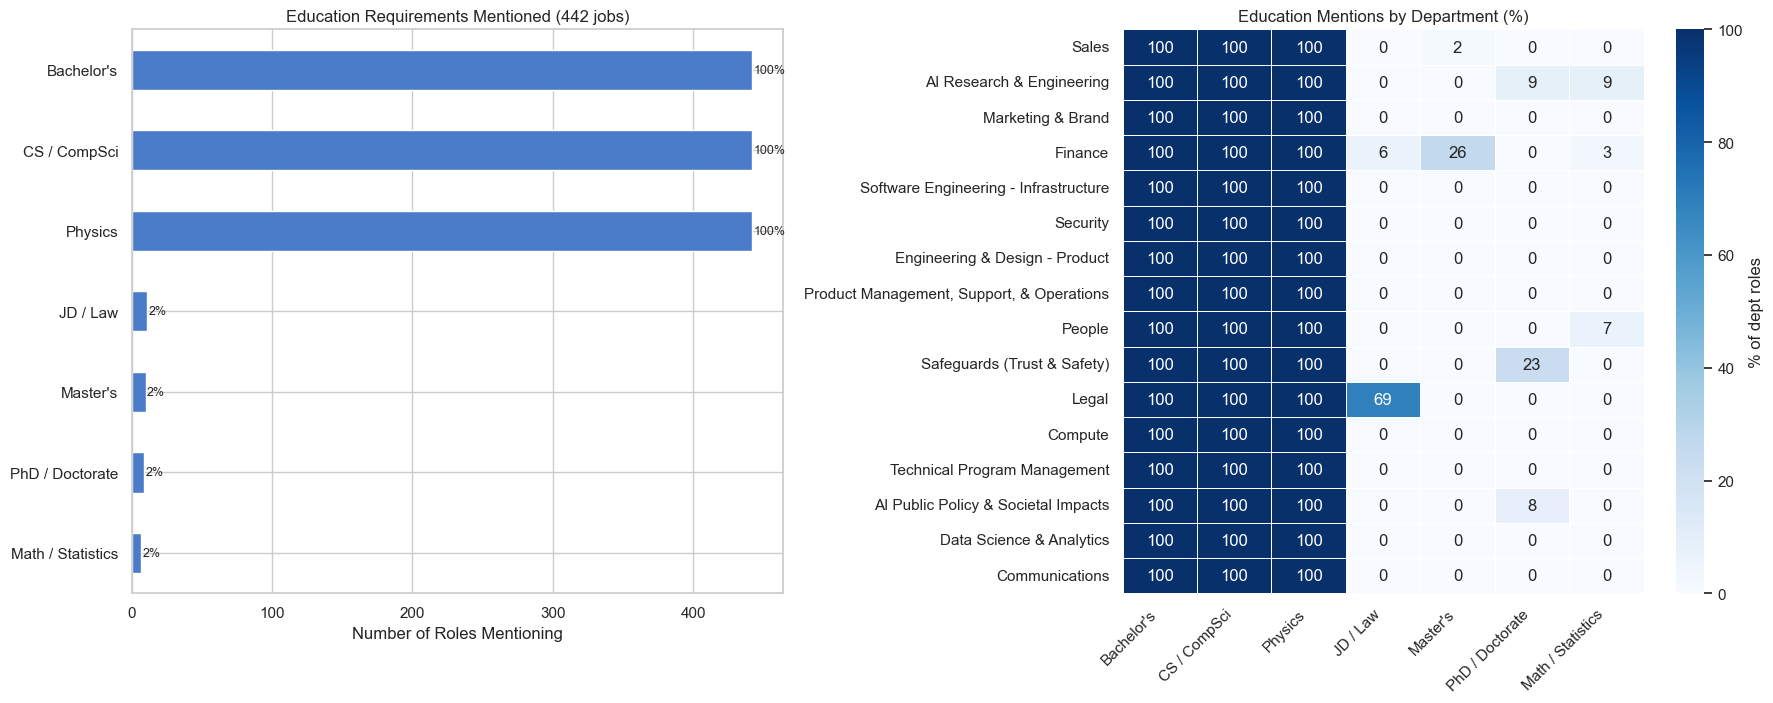

In [21]:
# Education requirement patterns
EDU_PATTERNS = {
    "PhD / Doctorate": r"\bPh\.?D\b|\bdoctora[lt]e?\b",
    "Master's": r"\bMaster'?s?\b|\bM\.?S\.?\b(?= in| degree)|\bMBA\b",
    "Bachelor's": r"\bBachelor'?s?\b|\bB\.?S\.?\b(?= in| degree)|\bB\.?A\.?\b(?= in| degree)|\bundergraduate degree\b",
    "CS / CompSci": r"\bcomputer science\b|\bCS\b(?= degree| or)",
    "Math / Statistics": r"\bmathematics\b|\bstatistics\b|\bmath\b(?= or| degree)",
    "Physics": r"\bphysics\b",
    "JD / Law": r"\bJ\.?D\.?\b|\blaw degree\b|\bbar\b(?= admission| exam)",
}

edu_counts = {}
for label, pattern in EDU_PATTERNS.items():
    count = df_nlp["description_md"].str.contains(pattern, flags=re.I, na=False).sum()
    edu_counts[label] = count

edu_series = pd.Series(edu_counts).sort_values(ascending=False)

# Education by department — all real departments
top_depts_edu = [d for d in df_nlp["department"].value_counts().index if d != "Other"]
edu_dept = pd.DataFrame(index=top_depts_edu, columns=edu_series.index, dtype=float)
for dept in top_depts_edu:
    dept_descs = df_nlp.loc[df_nlp["department"] == dept, "description_md"]
    for label, pattern in EDU_PATTERNS.items():
        cnt = dept_descs.str.contains(pattern, flags=re.I, na=False).sum()
        edu_dept.loc[dept, label] = cnt / len(dept_descs) * 100 if len(dept_descs) > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(top_depts_edu) * 0.45)))

# Overall counts
edu_series.plot.barh(ax=axes[0], color="#4a7cc9")
axes[0].set_title(f"Education Requirements Mentioned ({len(df_nlp)} jobs)")
axes[0].set_xlabel("Number of Roles Mentioning")
axes[0].set_ylabel("")
for i, (label, count) in enumerate(edu_series.items()):
    axes[0].text(count + 1, i, f"{count/len(df_nlp)*100:.0f}%", va="center", fontsize=9)
axes[0].invert_yaxis()

# Heatmap by department
sns.heatmap(
    edu_dept.astype(float), annot=True, fmt=".0f", cmap="Blues",
    linewidths=0.5, ax=axes[1], cbar_kws={"label": "% of dept roles"},
)
axes[1].set_title("Education Mentions by Department (%)")
axes[1].set_ylabel("")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## NLP-6. Description Length vs Salary

Do longer, more detailed job postings correlate with higher or lower pay?

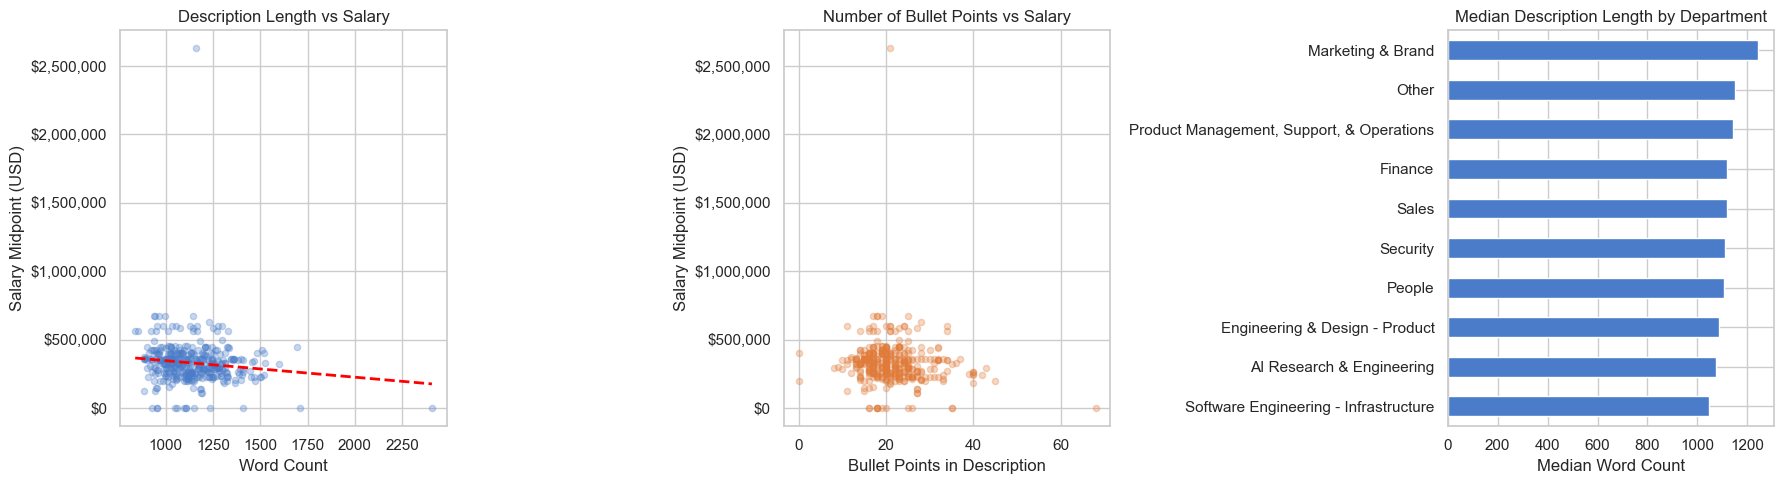

CORRELATIONS WITH SALARY
  Word count ↔ Salary: r = -0.118
  Bullets    ↔ Salary: r = -0.103


In [22]:
df_nlp["desc_len"] = df_nlp["description_md"].str.len()
df_nlp["desc_words"] = df_nlp["description_md"].str.split().str.len()

# Count bullet points as a proxy for how structured/detailed the listing is
df_nlp["n_bullets"] = df_nlp["description_md"].str.count(r"^\s*[\*\-]\s", flags=re.MULTILINE)

df_len_sal = df_nlp.dropna(subset=["mid_usd", "desc_words"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Word count vs salary
axes[0].scatter(df_len_sal["desc_words"], df_len_sal["mid_usd"], alpha=0.3, s=20, c="#4a7cc9")
z = np.polyfit(df_len_sal["desc_words"], df_len_sal["mid_usd"], 1)
x_fit = np.linspace(df_len_sal["desc_words"].min(), df_len_sal["desc_words"].max(), 50)
axes[0].plot(x_fit, np.poly1d(z)(x_fit), "--", color="red", linewidth=2)
axes[0].set_title("Description Length vs Salary")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Salary Midpoint (USD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Bullet count vs salary
axes[1].scatter(df_len_sal["n_bullets"], df_len_sal["mid_usd"], alpha=0.3, s=20, c="#e07b39")
axes[1].set_title("Number of Bullet Points vs Salary")
axes[1].set_xlabel("Bullet Points in Description")
axes[1].set_ylabel("Salary Midpoint (USD)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Description length by department
dept_len = df_nlp.groupby("department")["desc_words"].median().sort_values(ascending=True)
dept_len = dept_len[dept_len.index.isin(df_nlp["department"].value_counts().head(10).index)]
dept_len.plot.barh(ax=axes[2], color="#4a7cc9")
axes[2].set_title("Median Description Length by Department")
axes[2].set_xlabel("Median Word Count")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

corr = df_len_sal[["desc_words", "n_bullets", "mid_usd"]].corr()
print("CORRELATIONS WITH SALARY")
print(f"  Word count ↔ Salary: r = {corr.loc['desc_words', 'mid_usd']:.3f}")
print(f"  Bullets    ↔ Salary: r = {corr.loc['n_bullets', 'mid_usd']:.3f}")